In [1]:
import os
# 锁死 BLAS 单线程，防止 joblib worker 内部多线程导致 144 线程抢 12 核 / 内存爆炸。
# 这几行必须在 import numpy 之前。
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")  # macOS Apple Accelerate / vecLib
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
from pipelines import estimate_regression_models, estimate_regression_models_tl
from joblib import Parallel, delayed
from tqdm import tqdm
import json

In [2]:
def compute_errnorm_gaussian(i, p, n, nn, beta_0, w_0, sigma, sigma1, psi_delta=1.35, psi_eta=0.1, tau_range=None, alphas_c=None):
    np.random.seed(i) # 为每个并行工作设置独立的种子

    # --- 数据生成 ---
    X = np.random.normal(size=(n, p))
    Y = X @ beta_0 + np.random.normal(0, sigma, n)

    X1 = np.random.normal(size=(nn, p))
    Y1 = X1 @ w_0 + np.random.normal(0, sigma1, nn)

    if tau_range is None:
        tau_range = np.logspace(-4, 1, 15) # 更细致的 tau 范围

    # 调用函数
    estimated_models = estimate_regression_models(
        X, Y,
        X1, Y1,
        delta_param=psi_delta,
        eta_param=psi_eta,
        tau_range=tau_range,
        alphas_custom=alphas_c
    )

    beta_sr  = estimated_models["single_robust_ridge"]["betahat"]
    beta_tr  = estimated_models["transfer_robust_ridge"]["betahat"]
    beta_ada = estimated_models["adaptive"]["betahat"]
    beta_pr  = estimated_models["pooled_robust_ridge"]["betahat"]
    beta_sl  = estimated_models["single_task_lasso"]["betahat"]
    beta_tl  = estimated_models["transfer_lasso"]["betahat"]

    errnorm_sr  = np.sum((beta_sr  - beta_0)**2) / np.sum(beta_0**2)
    errnorm_tr  = np.sum((beta_tr  - beta_0)**2) / np.sum(beta_0**2)
    errnorm_ada = np.sum((beta_ada - beta_0)**2) / np.sum(beta_0**2)
    errnorm_pr  = np.sum((beta_pr  - beta_0)**2) / np.sum(beta_0**2)
    errnorm_sl  = np.sum((beta_sl  - beta_0)**2) / np.sum(beta_0**2)
    errnorm_tl  = np.sum((beta_tl  - beta_0)**2) / np.sum(beta_0**2)

    return errnorm_sr, errnorm_tr, errnorm_ada, errnorm_pr, errnorm_sl, errnorm_tl


In [3]:
def run_simulation_cv(p, n, K, dd, n_jobs=-1, tau_range=None, alphas_c=None):
    """
    运行完整的模拟研究，使用CV优化tau参数。

    Args:
        p (int): 特征维度
        n (int): 目标任务样本量
        K (int): 模拟重复次数
        dd (float): 控制delta_0范数的系数
        n_jobs (int): 并行使用的CPU核心数
        tau_range (array, optional): 用于CV的tau候选值范围

    Returns:
        tuple: (mean_errnorm, std_errnorm, errnorm_df, ridge_tau_stats)
    """
    # 简化输出，只显示进度条
    # print(f"Starting CV simulation with p={p}, n={n}, K={K}, dd={dd}")

    # --- 在函数内部定义固定的模拟参数 ---
    nn = n * 2          # 源任务样本量
    sigma = 1           # 目标任务噪声标准差
    sigma1 = 2          # 源任务噪声标准差
    psi_delta = 1.35    # psi 函数参数 delta
    psi_eta = 0.1       # psi 函数参数 eta
    kappa = p // n      # 维度样本比

    if tau_range is None:
        tau_range = np.logspace(-3, 3, 10)  # 默认的tau值范围

    # --- 生成固定的真实系数 (在所有 K 次运行中保持不变) ---
    rng = np.random.RandomState(1) # 使用固定的种子以保证 beta_0, w_0 可复现
    beta_0 = rng.uniform(size=p)
    beta_0 /= np.linalg.norm(beta_0, 2)

    # delta_0 = rng.uniform(size=p)
    # delta_0 /= np.linalg.norm(delta_0, 2) * dd
    delta_0 = np.ones(p) * dd / np.sqrt(p)  # 固定的 delta_0

    w_0 = beta_0 - delta_0

    # --- 使用 joblib 进行并行计算 ---
    # 简化输出，只显示进度条
    # print(f"Running {K} simulations in parallel using {n_jobs if n_jobs > 0 else os.cpu_count()} cores...")
    results_list = Parallel(n_jobs=n_jobs)(
        delayed(compute_errnorm_gaussian)(
            i, p, n, nn, beta_0, w_0, sigma, sigma1, psi_delta, psi_eta, tau_range, alphas_c
        )
        for i in tqdm(range(K), desc=f"dd={dd:.3f}")
    )

    # --- 结果处理 ---
    # 6 个 errnorm: SR / TR / TR-Ada / PR / SL / TL
    errnorm_data = [r[:6] for r in results_list]

    errnorm = np.array(errnorm_data)  # K x 6 array

    # 处理可能的 NaN 值 (如果某些运行失败)
    mean_errnorm = np.nanmean(errnorm, axis=0)
    std_errnorm = np.nanstd(errnorm, axis=0)



    # 简化输出，不显示每个dd的详细结果
    """
    print("\nSimulation finished.")
    print("-" * 30)
    print(f"Parameters: p={p}, n={n}, K={K}, kappa={kappa}, dd={dd}")
    print("Mean Error (Std Dev):")
    method_names = ['Single Robust Ridge', 'Trans Robust Ridge', 'Pooled Robust Ridge', 'Single Task Lasso', 'Trans Lasso']
    for idx, name in enumerate(method_names):
         print(f"  {name:<20}: {mean_errnorm[idx]:.4f} ({std_errnorm[idx]:.4f})  (Failures: {nan_counts[idx]}/{K})")
    print("-" * 30)
    """

    # --- 保存结果 ---
    errnorm_df = pd.DataFrame(errnorm, columns=['Single RR', 'Trans RR', 'Trans-RR-Ada', 'Pooled RR', 'Single Lasso', 'Trans Lasso'])

    return mean_errnorm, std_errnorm, errnorm_df


In [4]:
p_val = 400
n_val = 400
K_val = 1000    # 由于CV会显著增加计算时间，可以减少重复次数
n_jobs_val = 8  # 使用所有 CPU 核心

# print(f"Running CV simulations with p={p_val}, n={n_val}, K={K_val}")

# 设置CV的tau范围
tau_range_val = np.logspace(0, 1, 10, base=3)
# alpha_range_val = np.logspace(-5, 0, 50)
alpha_range_val = None

# 要测试的 dd 值
dd_values = np.power(np.e, np.arange(-2.0, 1.5, 0.5))

# 存储所有运行的结果
all_results = {}

for dd_val in dd_values:
    # 简化输出，移除分隔线
    # print(f"\n\n{'=' * 50}")
    # print(f"Running CV simulation with dd = {dd_val}")
    # print(f"{'=' * 50}")

    # 运行模拟
    mean_err, std_err, results_df = run_simulation_cv(
        p=p_val, n=n_val, K=K_val, dd=dd_val, n_jobs=n_jobs_val, tau_range=tau_range_val, alphas_c=alpha_range_val
    )

    # 存储结果
    all_results[dd_val] = {
        'mean_err': mean_err,
        'std_err': std_err,
        'results_df': results_df
    }


# 汇总结果
method_names = ['Single RR', 'Trans RR', 'Pooled RR', 'Single Lasso', 'Trans Lasso']

print("\n\n" + "=" * 100)
print("Summary of CV Results Across Different dd Values - Mean (Std Dev)".center(100))
print("=" * 100)

# 打印表头
header = f"{'dd':<8}"
for method in method_names:
    header += f"{method:<25}"
print(header)
print("-" * 100)

# 按照dd值组织结果，合并均值和标准差
for dd_val in dd_values:
    results_line = f"{dd_val:.3f}".ljust(8)
    for i, method in enumerate(method_names):
        mean = all_results[dd_val]['mean_err'][i]
        std = all_results[dd_val]['std_err'][i]
        results_line += f"{mean:.4f} ({std:.4f})".ljust(25)
    print(results_line)

dd=2.718: 100%|██████████| 1000/1000 [11:42<00:00,  1.42it/s]




                 Summary of CV Results Across Different dd Values - Mean (Std Dev)                  
dd      Single RR                Trans RR                 Pooled RR                Single Lasso             Trans Lasso              
----------------------------------------------------------------------------------------------------
0.135   0.6390 (0.0413)          0.5394 (0.0380)          0.6080 (0.0331)          0.8896 (0.0587)          0.8572 (0.0627)          
0.223   0.6390 (0.0413)          0.5533 (0.0381)          0.6317 (0.0365)          0.8896 (0.0587)          0.8656 (0.0609)          
0.368   0.6390 (0.0413)          0.5737 (0.0385)          0.6764 (0.0421)          0.8896 (0.0587)          0.8758 (0.0595)          
0.607   0.6390 (0.0413)          0.6021 (0.0398)          0.7582 (0.0451)          0.8896 (0.0587)          0.8863 (0.0591)          
1.000   0.6390 (0.0413)          0.6477 (0.0441)          0.8722 (0.0297)          0.8896 (0.0587)          0.8977 (0.0639)   

In [5]:
filename = f"res/1gaussian_cv_results_p{p_val}_simu{K_val}.json"

converted_results = {}
for dd_val in all_results:
    converted_results[str(dd_val)] = {
        'mean_err': all_results[dd_val]['mean_err'].tolist(),
        'std_err': all_results[dd_val]['std_err'].tolist(),
        'results_df': all_results[dd_val]['results_df'].to_dict()
    }

with open(filename, 'w') as f:
    json.dump(converted_results, f, indent=4)

print(f"结果已保存至: {filename}")

结果已保存至: res/1gaussian_cv_results_p400_simu1000.json


In [5]:
filename = f"res/gaussian_cv_results_p{p_val}_simu{K_val}.json"

converted_results = {}
for dd_val in all_results:
    converted_results[str(dd_val)] = {
        'mean_err': all_results[dd_val]['mean_err'].tolist(),
        'std_err': all_results[dd_val]['std_err'].tolist(),
        'results_df': all_results[dd_val]['results_df'].to_dict()
    }

with open(filename, 'w') as f:
    json.dump(converted_results, f, indent=4)

print(f"结果已保存至: {filename}")

结果已保存至: res/gaussian_cv_results_p400_simu500.json


In [7]:
rng = np.random.RandomState(2) # 使用固定的种子以保证 beta_0, w_0 可复现
b_0 = rng.uniform(size=200)
b_0 /= np.linalg.norm(b_0, 2)*2
np.linalg.norm(b_0, 2)

np.float64(0.5)

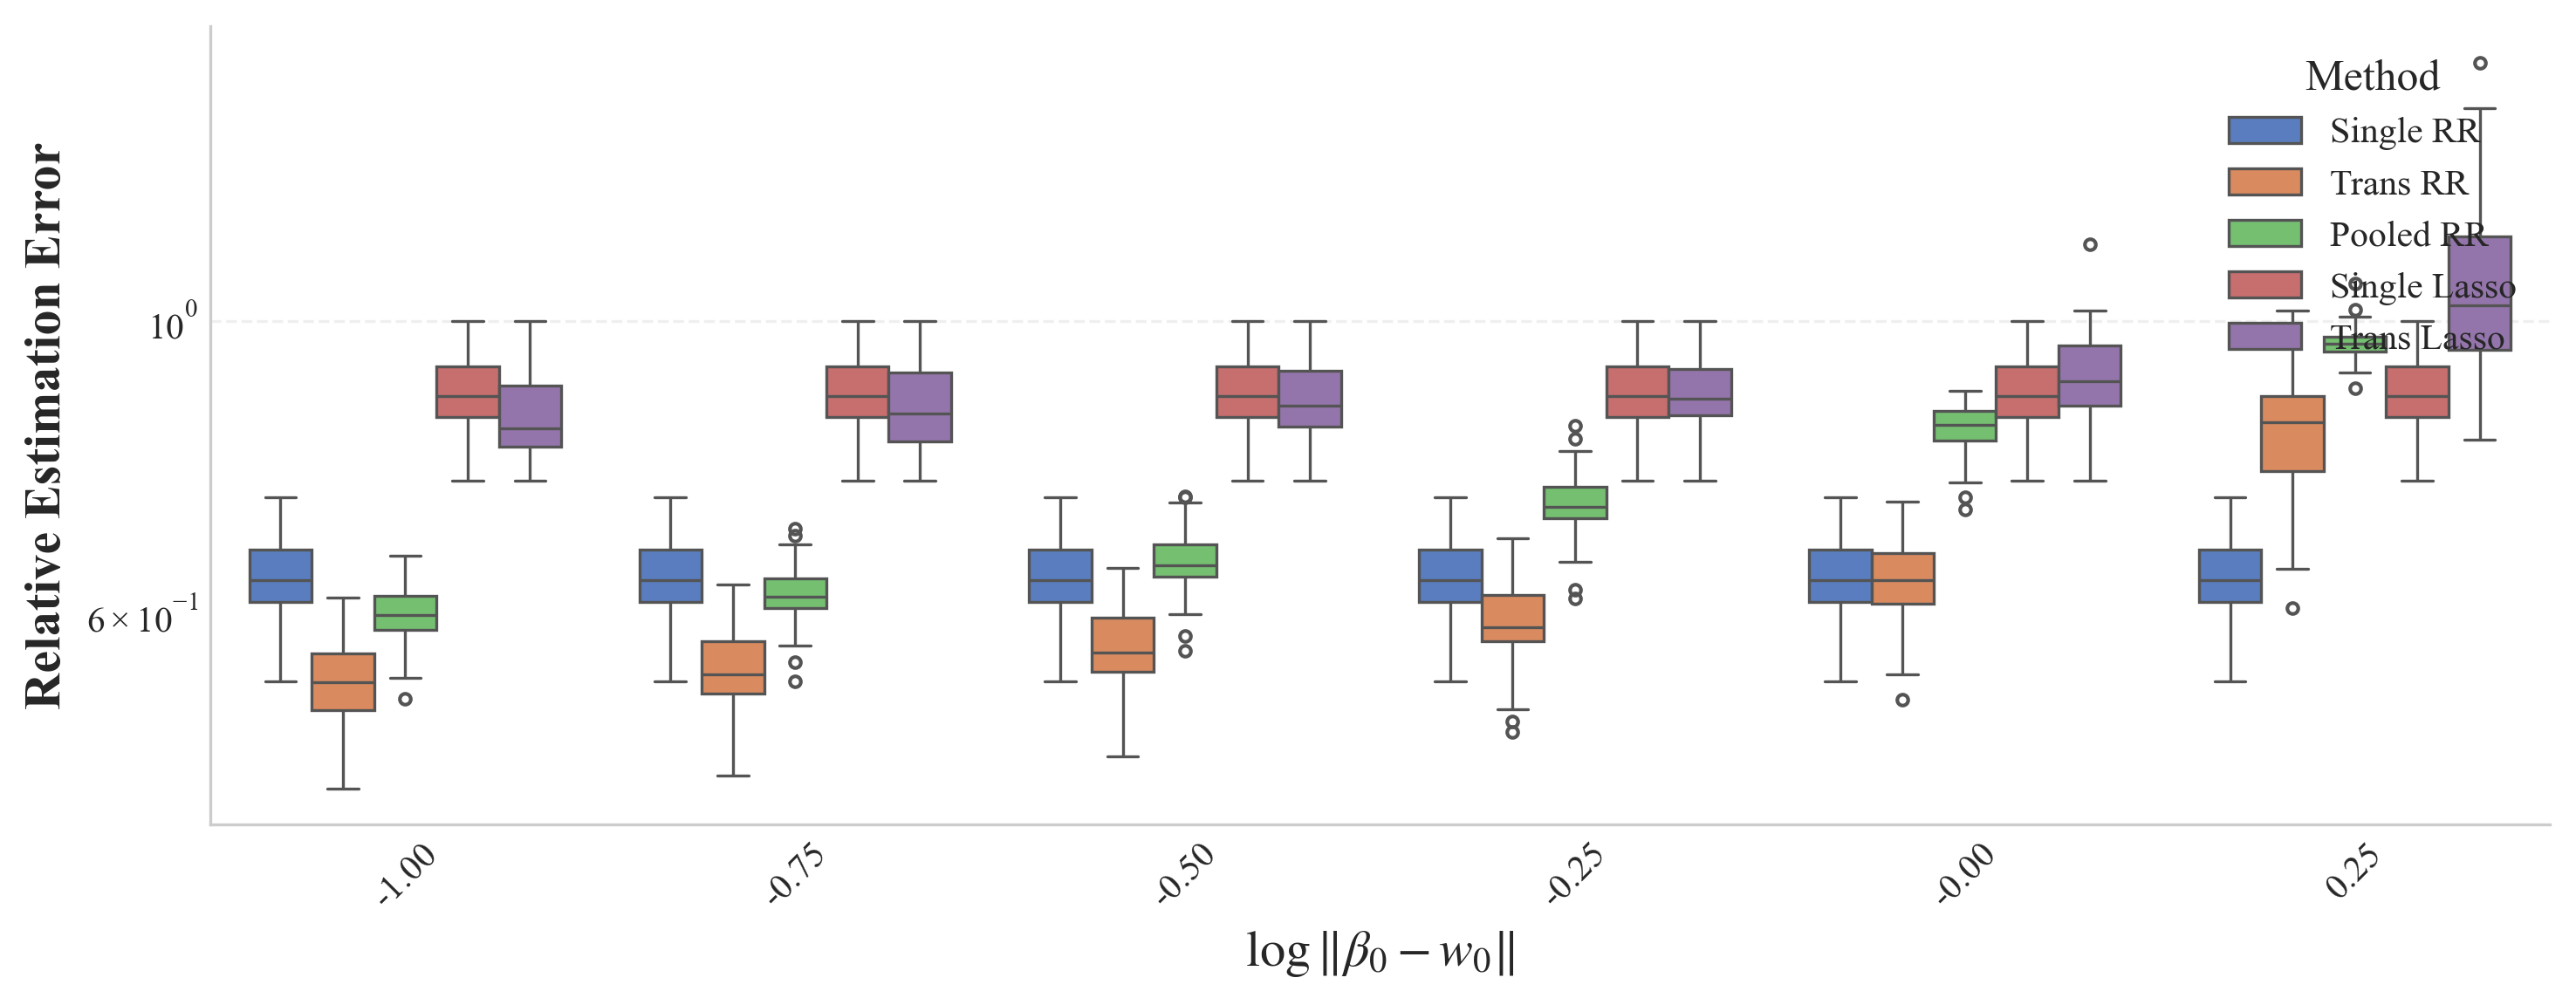

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import ScalarFormatter

# 准备数据
all_data = []
for dd_val in all_results:
    # 从results_df中获取数据
    df = all_results[dd_val]['results_df']

    # 计算log(dd_val)/2作为新的x轴值
    log_dd = -np.log(dd_val) / 2

    # 为每个方法添加dd值和log_dd值
    for method in df.columns:
        method_data = df[method]
        temp_df = pd.DataFrame({
            'dd': [dd_val] * len(method_data),
            'log_dd': [log_dd] * len(method_data),
            'method': [method] * len(method_data),
            'error': method_data
        })
        all_data.append(temp_df)

# 合并所有数据
plot_data = pd.concat(all_data, ignore_index=True)

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 设置图形大小和分辨率
plt.figure(figsize=(10, 4), dpi=300)

# 创建分组箱线图，使用log_dd作为x轴
ax = sns.boxplot(
    x='log_dd',  # 使用log(dd_val)/2作为x轴
    y='error',
    hue='method',
    data=plot_data,
    palette='muted',
    linewidth=0.8,
    fliersize=3
)

# 设置图表标签
plt.xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=14, fontweight='bold')  # 修改后的横坐标标题
plt.ylabel('Relative Estimation Error', fontsize=14, fontweight='bold')
plt.yscale('log')


# 正确设置x轴的刻度和标签
log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
ax.set_xticks(range(len(log_dd_values_sorted)))
ax.set_xticklabels([f"{val:.2f}" for val in log_dd_values_sorted], rotation=45)

# 将图例放在图内部的右上角
plt.legend(title='Method', loc='upper right', framealpha=0.9,
           edgecolor='black', fancybox=True, fontsize=10)

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.3, axis='y')


# 设置坐标轴线条粗细
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# 设置坐标轴刻度线的粗细
ax.tick_params(width=0.8)

# 调整布局，确保所有元素都能显示
plt.tight_layout()

# 保存为PDF
plt.savefig('error_comparison_boxplot.pdf', format='pdf', bbox_inches='tight')

# 显示图表
plt.show()

In [18]:
np.e

2.718281828459045

In [20]:
p_val = 200
n_val = 200
K_val = 50    # 由于CV会显著增加计算时间，可以减少重复次数
n_jobs_val = 8  # 使用所有 CPU 核心

# print(f"Running CV simulations with p={p_val}, n={n_val}, K={K_val}")

# 设置CV的tau范围
tau_range_val = np.logspace(-2, 1, 10, base=3)

# 要测试的 dd 值
dd_values = np.power(2.0, np.arange(-2, 3.5, 0.5))

# 存储所有运行的结果
all_results = {}

for dd_val in dd_values:
    # 简化输出，移除分隔线
    # print(f"\n\n{'=' * 50}")
    # print(f"Running CV simulation with dd = {dd_val}")
    # print(f"{'=' * 50}")

    # 运行模拟
    mean_err, std_err, results_df = run_simulation_cv(
        p=p_val, n=n_val, K=K_val, dd=dd_val, n_jobs=n_jobs_val, tau_range=tau_range_val, alphas_c=None
    )

    # 存储结果
    all_results[dd_val] = {
        'mean_err': mean_err,
        'std_err': std_err,
        'results_df': results_df
    }


# 汇总结果
method_names = ['Single RR', 'Trans RR', 'Pooled RR', 'Single Lasso', 'Trans Lasso']

print("\n\n" + "=" * 100)
print("Summary of CV Results Across Different dd Values - Mean (Std Dev)".center(100))
print("=" * 100)

# 打印表头
header = f"{'dd':<8}"
for method in method_names:
    header += f"{method:<25}"
print(header)
print("-" * 100)

# 按照dd值组织结果，合并均值和标准差
for dd_val in dd_values:
    results_line = f"{dd_val:.3f}".ljust(8)
    for i, method in enumerate(method_names):
        mean = all_results[dd_val]['mean_err'][i]
        std = all_results[dd_val]['std_err'][i]
        results_line += f"{mean:.4f} ({std:.4f})".ljust(25)
    print(results_line)

dd=8.000: 100%|██████████| 50/50 [00:19<00:00,  2.63it/s]




                 Summary of CV Results Across Different dd Values - Mean (Std Dev)                  
dd      Single RR                Trans RR                 Pooled RR                Single Lasso             Trans Lasso              
----------------------------------------------------------------------------------------------------
0.250   0.6481 (0.0550)          3.0352 (0.5556)          3.7127 (1.1772)          0.8986 (0.1029)          4.8547 (1.0125)          
0.354   0.6481 (0.0550)          1.7549 (0.3061)          1.7390 (0.4001)          0.8986 (0.1029)          2.5617 (0.5709)          
0.500   0.6481 (0.0550)          1.0126 (0.1698)          1.0915 (0.1281)          0.8986 (0.1029)          1.3836 (0.2846)          
0.707   0.6481 (0.0550)          0.7327 (0.0878)          0.9266 (0.0392)          0.8986 (0.1029)          0.9918 (0.1583)          
1.000   0.6481 (0.0550)          0.6481 (0.0628)          0.8510 (0.0449)          0.8986 (0.1029)          0.9033 (0.1165)   